In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

In [3]:
DATA_PATH = Path("../data/processed/consommation_brest_daily.csv")

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

serie = df["consommation_moyenne_journaliere"]

train = serie.loc["2020-01-01":"2025-12-31"]
test = serie.loc["2026-01-01":"2026-05-31"]

print("Train :", train.index.min(), "->", train.index.max(), "|", len(train), "jours")
print("Test :", test.index.min(), "->", test.index.max(), "|", len(test), "jours")

Train : 2020-01-01 00:00:00 -> 2025-12-31 00:00:00 | 2192 jours
Test : 2026-01-01 00:00:00 -> 2026-05-31 00:00:00 | 151 jours


In [4]:
model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=15498.448, Time=0.52 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=26840.530, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=23936.808, Time=0.21 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=15515.637, Time=0.32 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=15754.708, Time=0.25 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=15177.426, Time=1.27 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=15519.075, Time=0.74 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=1.16 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=1.01 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=15499.657, Time=0.68 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=15510.485, Time=0.86 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=15221.378, Time=1.12 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=15471.841, Time=1.60 sec

Best model:  ARIMA(3,0,2)(0,0,0)[0] 

In [5]:
forecast = model.predict(n_periods=len(test))
forecast = pd.Series(forecast, index=test.index, name="prediction_arima")

forecast.head()

date
2026-01-01    163.765629
2026-01-02    167.680764
2026-01-03    161.673640
2026-01-04    160.434843
2026-01-05    166.967235
Name: prediction_arima, dtype: float64

In [6]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("ARIMA avec pmdarima")
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

ARIMA avec pmdarima
MAE : 51.19402201602016
RMSE : 55.20036157832518
MAPE : 85.25860360172108


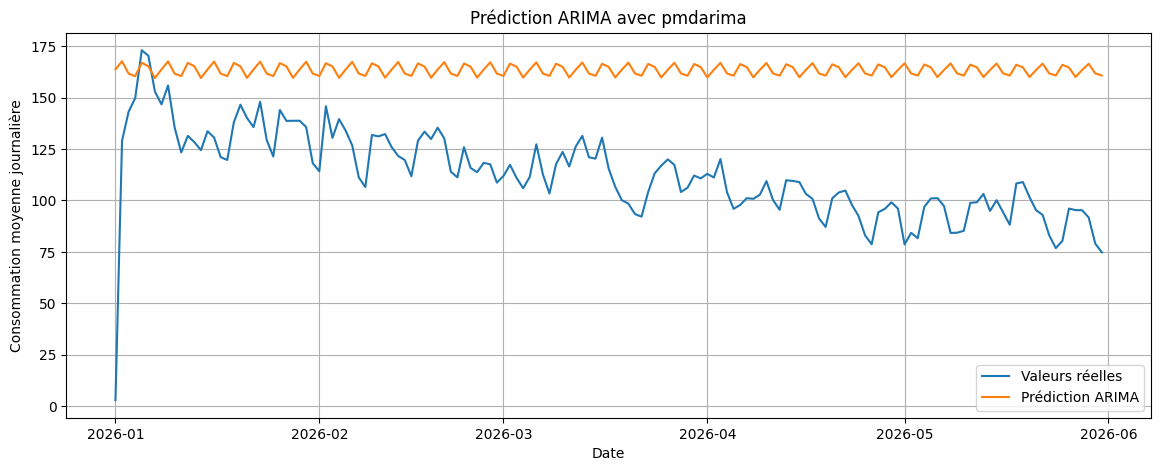

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Valeurs réelles")
plt.plot(forecast.index, forecast, label="Prédiction ARIMA")
plt.title("Prédiction ARIMA avec pmdarima")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Modèle SARIMA sélectionné automatiquement avec saisonnalité hebdomadaire
model = auto_arima(
    train,
    seasonal=True,
    m=7,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

predictions_j1 = []

# Prédiction glissante à J+1
for date, real_value in test.items():
    # Prédiction du prochain jour
    pred = model.predict(n_periods=1)

    # Récupération robuste de la valeur prédite
    pred_value = float(np.asarray(pred).ravel()[0])

    predictions_j1.append(pred_value)

    # Mise à jour du modèle avec la vraie valeur observée
    model.update(real_value)

# Conversion en Series pandas
predictions_j1 = pd.Series(predictions_j1, index=test.index, name="prediction_j1")

predictions_j1.head()

date
2026-01-01    159.356200
2026-01-02     16.503789
2026-01-03    115.060128
2026-01-04    120.067078
2026-01-05    154.286724
Name: prediction_j1, dtype: float64

In [23]:
import joblib
from pathlib import Path

# Chemin vers le dossier models à la racine du projet
MODEL_PATH = Path("../models/sarima_j1_pmdarima.pkl")

# Création du dossier models si besoin
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Sauvegarde du modèle
joblib.dump(model, MODEL_PATH)

print(f"Modèle sauvegardé ici : {MODEL_PATH}")

Modèle sauvegardé ici : ../models/sarima_j1_pmdarima.pkl


In [20]:
print(model.order)
print(model.seasonal_order)

(1, 0, 2)
(1, 0, 1, 7)


Le modèle ARIMA sélectionné automatiquement est un ARIMA(1,0,2). 
*Cela signifie qu’il utilise une valeur passée de la série, qu’aucune différenciation n’est appliquée, 
et que deux erreurs passées sont prises en compte pour ajuster les prédictions.

In [21]:
mae_j1 = mean_absolute_error(test, predictions_j1)
rmse_j1 = np.sqrt(mean_squared_error(test, predictions_j1))
mape_j1 = np.mean(np.abs((test - predictions_j1) / test)) * 100

print("SARIMA J+1 avec pmdarima")
print("MAE :", mae_j1)
print("RMSE :", rmse_j1)
print("MAPE :", mape_j1)

SARIMA J+1 avec pmdarima
MAE : 7.388789884821615
RMSE : 17.39657105069388
MAPE : 41.27441764725275


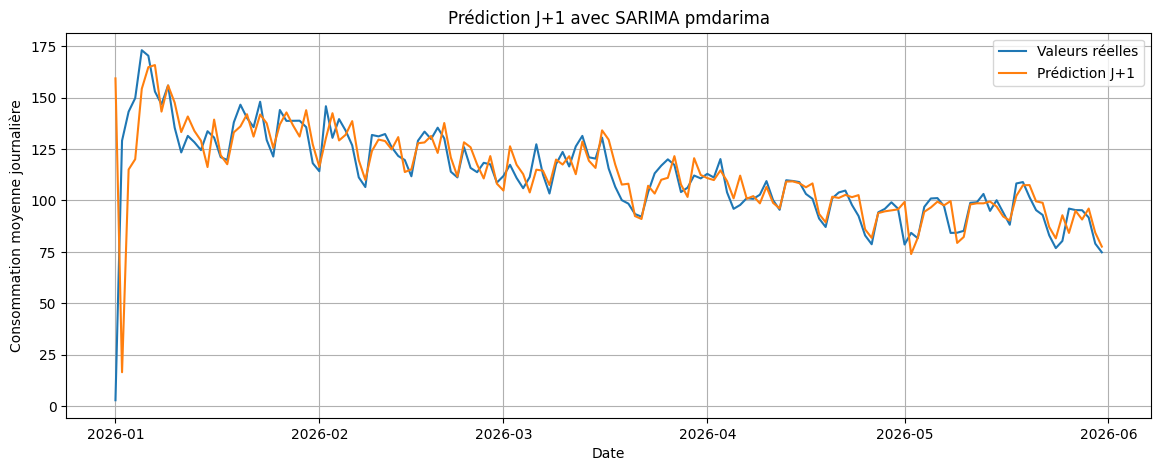

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Valeurs réelles")
plt.plot(predictions_j1.index, predictions_j1, label="Prédiction J+1")
plt.title("Prédiction J+1 avec SARIMA pmdarima")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Modèle SARIMA sélectionné automatiquement avec saisonnalité hebdomadaire
model_j3 = auto_arima(
    train,
    seasonal=True,
    m=7,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

predictions_j3 = []
dates_j3 = []

# Prédiction glissante à J+3
for i, (date, real_value) in enumerate(test.items()):
    # On prédit les 3 prochains jours
    pred = model_j3.predict(n_periods=3)

    # On récupère la prédiction du 3e jour
    pred_value = float(np.asarray(pred).ravel()[-1])

    # La prédiction correspond à la date située 3 jours après l'historique actuel
    target_index = i + 2

    if target_index < len(test):
        target_date = test.index[target_index]
        predictions_j3.append(pred_value)
        dates_j3.append(target_date)

    # Mise à jour du modèle avec la vraie valeur observée du jour
    model_j3.update(real_value)

# Conversion en Series pandas
predictions_j3 = pd.Series(predictions_j3, index=dates_j3, name="prediction_j3")

predictions_j3.head()

2026-01-03    147.831321
2026-01-04     36.957418
2026-01-05    116.188671
2026-01-06    130.793262
2026-01-07    149.194015
Name: prediction_j3, dtype: float64

In [17]:
# On aligne les vraies valeurs avec les dates prédites
test_j3 = test.loc[predictions_j3.index]

mae_j3 = mean_absolute_error(test_j3, predictions_j3)
rmse_j3 = np.sqrt(mean_squared_error(test_j3, predictions_j3))
mape_j3 = np.mean(np.abs((test_j3 - predictions_j3) / test_j3)) * 100

print("SARIMA J+3 avec pmdarima")
print("MAE :", mae_j3)
print("RMSE :", rmse_j3)
print("MAPE :", mape_j3)

SARIMA J+3 avec pmdarima
MAE : 8.475068205696983
RMSE : 14.218822638781763
MAPE : 7.448728069204524


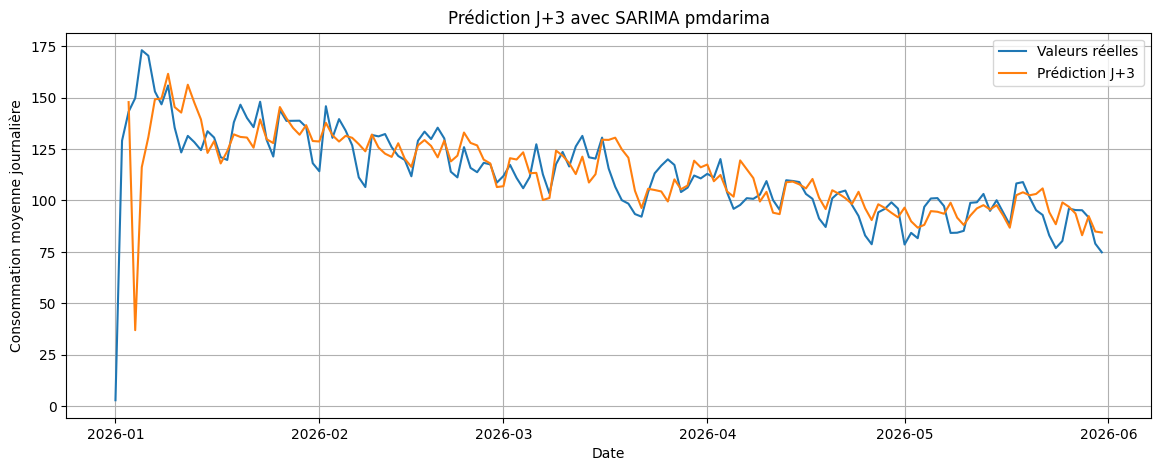

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(test.index, test, label="Valeurs réelles")
plt.plot(predictions_j3.index, predictions_j3, label="Prédiction J+3")

plt.title("Prédiction J+3 avec SARIMA pmdarima")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()